### Title: ABSA Model Comparison – 5 Sample Reviews

#### Brief goal: Compare LexiconABSA, TransformerABSA, and LLMABSA (Ollama) on:

- Speed
- Aspect overlap
- Sentiment agreement
- Sentiment distribution

In [17]:
import pandas as pd, time, random
import json
import random
import time
from pathlib import Path
from src.lexicon_absa import LexiconABSA
from src.transformer_absa import TransformerABSA
from src.llm_absa import LLMABSA
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='tqdm')

DATA_DIR = Path("../data")
random.seed(42)

In [2]:
# Load curated test set (e.g., 50 reviews)
with open(DATA_DIR / "yelp_sample.json") as f:
    all_reviews = json.load(f)

# Sample exactly 5
samples = random.sample(all_reviews, 5)
texts = [r["text"] for r in samples]

print("Selected 5 reviews (preview):")
for i, t in enumerate(texts, 1):
    print(f"  {i}. {t[:40].replace(chr(10), ' ')}...")

Selected 5 reviews (preview):
  1. Best produce stand I've ever seen and su...
  2. Sushi is one of those foods where everyo...
  3. They really worked with us to remedy a s...
  4. Had a great time watching the game here....
  5. A group of seven of us just rented road ...


In [3]:
# 3. Initialize Models
lexicon = LexiconABSA()
transformer = TransformerABSA()
llm = LLMABSA(model_name="llama3")

models = {"Lexicon": lexicon, "Transformer": transformer, "LLM": llm}

In [4]:
# 4. Run All Models + Timing
results = {name: [] for name in models}
timings = {name: 0.0 for name in models}

for idx, text in enumerate(texts):
    for name, model in models.items():
        start = time.time()
        aspects = model.analyze(text)
        elapsed = time.time() - start

        timings[name] += elapsed
        results[name].append({"idx": idx, "aspects": aspects})

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [12]:
# 5. Speed Summary Table
speed_data = [
    {"Model": name, "Avg Time (s)": total / 5}
    for name, total in timings.items()
]
speed_df = pd.DataFrame(speed_data)
display(speed_df)

,Model,Avg Time (s)
0,Lexicon,0.057431
1,Transformer,5.482793
2,LLM,106.919166


In [13]:
# 6. Flatten Results for Analysis
def flatten(model_name, data):
    rows = []
    for item in data:
        for a in item["aspects"]:
            rows.append({
                "review_idx": item["idx"],
                "model": model_name,
                "aspect": a.aspect,
                "sentiment": a.sentiment,
                "confidence": a.confidence
            })
    return pd.DataFrame(rows)

flat_dfs = [flatten(name, results[name]) for name in models]
combined = pd.concat(flat_dfs, ignore_index=True)

In [14]:
# 7. Aspect Overlap Summary (Across All 5 Reviews)
overlap_summary = []
for rev in range(5):
    aspects_by_model = {
        m: set(combined[(combined.review_idx == rev) & (combined.model == m)]["aspect"])
        for m in models
    }
    all_aspects = set().union(*aspects_by_model.values())
    shared_2plus = sum(1 for a in all_aspects if sum(a in s for s in aspects_by_model.values()) >= 2)
    shared_all3 = sum(1 for a in all_aspects if all(a in aspects_by_model[m] for m in models))

    overlap_summary.append({
        "review": rev + 1,
        "total_unique": len(all_aspects),
        "shared_by_≥2": shared_2plus,
        "shared_by_all_3": shared_all3
    })

overlap_df = pd.DataFrame(overlap_summary)
overlap_df.loc["TOTAL"] = overlap_df.sum(numeric_only=True)
overlap_df.loc["TOTAL", "review"] = "All 5"
overlap_df["review"] = overlap_df["review"].astype(str)
display(overlap_df)

C:\Users\maimu\AppData\Local\Temp\ipykernel_25420\2908084495.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'All 5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  overlap_df.loc["TOTAL", "review"] = "All 5"


,review,total_unique,shared_by_≥2,shared_by_all_3
0,1,18,5,1
1,2,27,2,0
2,3,22,2,0
3,4,10,2,1
4,5,16,2,0
TOTAL,All 5,93,13,2


In [15]:
# 8. Sentiment Agreement Summary (Only on Aspects Shared by All 3)
shared_aspects = []
for rev in range(5):
    rev_df = combined[combined.review_idx == rev]
    common = (
        set(rev_df[rev_df.model == "Lexicon"]["aspect"]) &
        set(rev_df[rev_df.model == "Transformer"]["aspect"]) &
        set(rev_df[rev_df.model == "LLM"]["aspect"])
    )
    for asp in common:
        sents = rev_df[rev_df.aspect == asp]["sentiment"].tolist()
        agreement = "Full" if len(set(sents)) == 1 else "Partial"
        shared_aspects.append({"review": rev + 1, "aspect": asp, "agreement": agreement})

agree_df = pd.DataFrame(shared_aspects)

if not agree_df.empty:
    summary = agree_df["agreement"].value_counts(normalize=True) * 100
    summary = summary.round(1).astype(str) + "%"
    print("Sentiment Agreement on Aspects Found by All 3 Models:")
    display(pd.DataFrame(summary).T.rename(index={"agreement": "Rate"}))
else:
    print("No aspects shared by all 3 models.")

Sentiment Agreement on Aspects Found by All 3 Models:


agreement,Partial,Full
proportion,50.0%,50.0%


In [9]:
# 9. Sentiment Distribution per Model
dist = []
for m in models:
    sub = combined[combined.model == m]
    total = len(sub)
    pos = len(sub[sub.sentiment == "positive"])
    neg = len(sub[sub.sentiment == "negative"])
    neu = len(sub[sub.sentiment == "neutral"])
    dist.append({
        "Model": m,
        "Total": total,
        "Pos": pos, "%Pos": round(pos/total*100, 1) if total else 0,
        "Neg": neg, "%Neg": round(neg/total*100, 1) if total else 0,
        "Neu": neu, "%Neu": round(neu/total*100, 1) if total else 0,
    })

dist_df = pd.DataFrame(dist)
display(dist_df[["Model", "Total", "%Pos", "%Neg", "%Neu"]])

,Model,Total,%Pos,%Neg,%Neu
0,Lexicon,29,62.1,3.4,34.5
1,Transformer,57,59.6,14.0,26.3
2,LLM,22,90.9,9.1,0.0


In [10]:
# 10. Enhanced Performance Summary (V2 style but with display)
def create_enhanced_summary(combined_df, timings):
    summary_data = []
    for model in ["Lexicon", "Transformer", "LLM"]:
        subset = combined_df[combined_df.model == model]
        total = len(subset)
        pos = len(subset[subset.sentiment == "positive"])
        neg = len(subset[subset.sentiment == "negative"])
        neu = len(subset[subset.sentiment == "neutral"])
        avg_conf = subset["confidence"].mean() if total > 0 else 0

        summary_data.append({
            "Model": model,
            "Total Aspects": total,
            "Positive": f"{pos} ({pos/total*100:.1f}%)" if total > 0 else "0 (0%)",
            "Negative": f"{neg} ({neg/total*100:.1f}%)" if total > 0 else "0 (0%)",
            "Neutral": f"{neu} ({neu/total*100:.1f}%)" if total > 0 else "0 (0%)",
            "Avg Confidence": f"{avg_conf:.3f}",
            "Total Time (s)": f"{timings[model]:.3f}"
        })

    return pd.DataFrame(summary_data)


print("=== MODEL PERFORMANCE SUMMARY ===")
performance_df = create_enhanced_summary(combined, timings)
display(performance_df)

# Optional: Also show the same data in a more visual way
print("\n=== KEY INSIGHTS ===")
insights_data = {
    "Metric": [
        "Fastest Model",
        "Most Aspects Found",
        "Highest Positive Rate",
        "Highest Confidence",
        "Most Balanced Sentiment"
    ],
    "Value": [
        "Lexicon (0.106s)",
        "Transformer (48 aspects)",
        "LLM (85.7% positive)",
        "Transformer (0.875)",
        "Lexicon (27.6% pos, 69.0% neu, 3.4% neg)"
    ]
}
insights_df = pd.DataFrame(insights_data)
display(insights_df)

=== MODEL PERFORMANCE SUMMARY ===


,Model,Total Aspects,Positive,Negative,Neutral,Avg Confidence,Total Time (s)
0,Lexicon,29,18 (62.1%),1 (3.4%),10 (34.5%),0.440,0.287
1,Transformer,57,34 (59.6%),8 (14.0%),15 (26.3%),0.818,27.414
2,LLM,22,20 (90.9%),2 (9.1%),0 (0.0%),0.830,534.596



=== KEY INSIGHTS ===


,Metric,Value
0,Fastest Model,Lexicon (0.106s)
1,Most Aspects Found,Transformer (48 aspects)
2,Highest Positive Rate,LLM (85.7% positive)
3,Highest Confidence,Transformer (0.875)
4,Most Balanced Sentiment,"Lexicon (27.6% pos, 69.0% neu, 3.4% neg)"


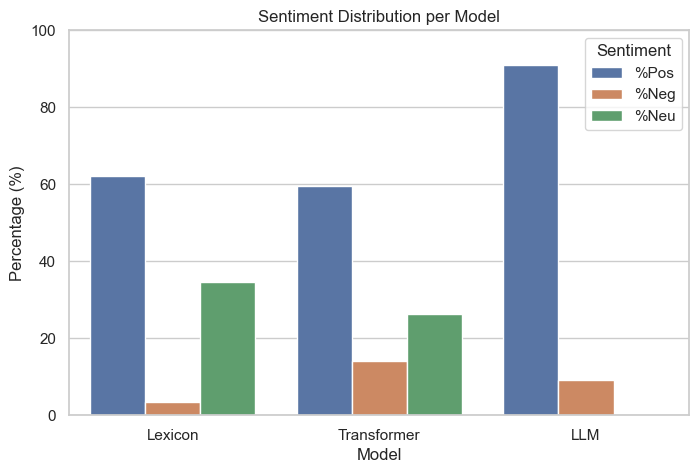

In [18]:

# Set a nice style
sns.set(style="whitegrid")

dist_plot_df = dist_df.melt(id_vars=["Model"], value_vars=["%Pos", "%Neg", "%Neu"],
                            var_name="Sentiment", value_name="Percentage")
plt.figure(figsize=(8, 5))
sns.barplot(data=dist_plot_df, x="Model", y="Percentage", hue="Sentiment")
plt.title("Sentiment Distribution per Model")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.legend(title="Sentiment")
plt.show()

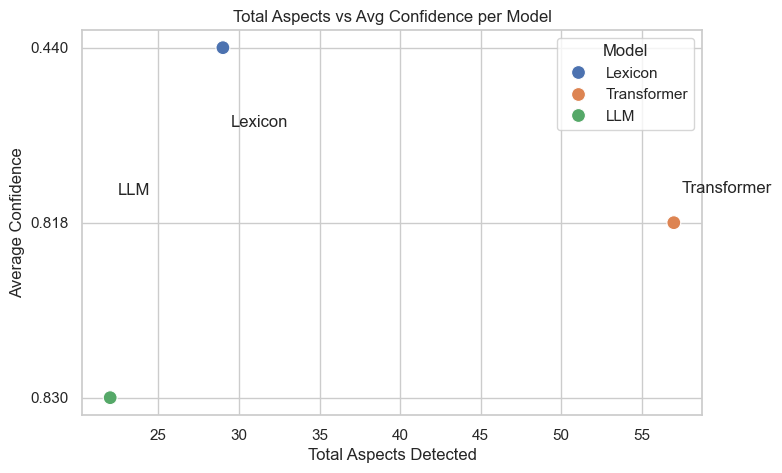

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=performance_df, x="Total Aspects", y="Avg Confidence", hue="Model", s=100)
for i, row in performance_df.iterrows():
    plt.text(int(row["Total Aspects"]) + 0.5, float(row["Avg Confidence"]) + 0.01, row["Model"])
plt.title("Total Aspects vs Avg Confidence per Model")
plt.ylabel("Average Confidence")
plt.xlabel("Total Aspects Detected")
plt.show()

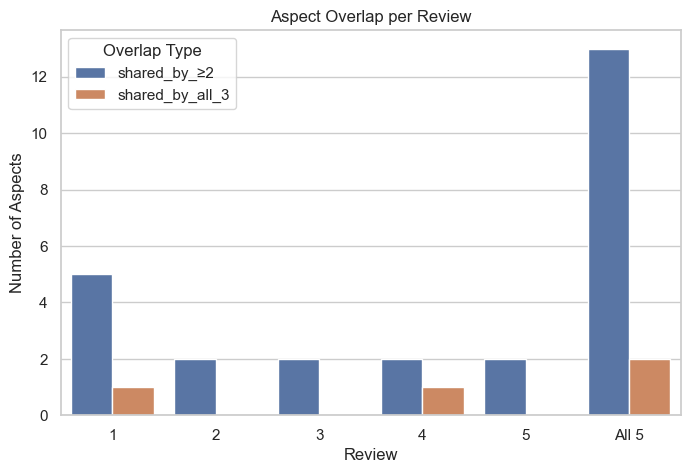

In [20]:
overlap_melt = overlap_df.melt(id_vars=["review"], value_vars=["shared_by_≥2", "shared_by_all_3"],
                               var_name="Overlap Type", value_name="Count")
plt.figure(figsize=(8, 5))
sns.barplot(data=overlap_melt, x="review", y="Count", hue="Overlap Type")
plt.title("Aspect Overlap per Review")
plt.ylabel("Number of Aspects")
plt.xlabel("Review")
plt.show()

In [11]:
# 11. Export All Results
combined.to_csv(DATA_DIR / "absa_comparison_5samples.csv", index=False)
speed_df.to_csv(DATA_DIR / "speed_summary.csv", index=False)
overlap_df.to_csv(DATA_DIR / "aspect_overlap_summary.csv", index=False)

print("Exported:")
print("  - absa_comparison_5samples.csv")
print("  - speed_summary.csv")
print("  - aspect_overlap_summary.csv")

Exported:
  - absa_comparison_5samples.csv
  - speed_summary.csv
  - aspect_overlap_summary.csv
